# Ejercicios: Tokenización, Part Of Speech, Lematización, WordCloud
Procesar los textos siguientes siguiendo los pasos indicados al final.

## Texto (Noticia):
The government has announced new measures to combat climate change. These measures include reducing carbon emissions and promoting renewable energy sources. The initiative aims to achieve net-zero emissions by 2050. Experts believe that these steps are crucial for the sustainability of our planet. The public is encouraged to participate in various programs to support this cause.

## Texto (Twitter):
Just watched an amazing football match! ⚽️ #Sports #Football @TeamA

Can't believe how good the game was last night! #Exciting @TeamB

The team played exceptionally well and deserved the win. #Victory 🏆

Feeling inspired after that match! #Motivation #SportsLife

What a goal by @Player1! Absolutely stunning! #GoalOfTheSeason


## Texto (Reseña de producto):
This phone is absolutely    fantastic . . . The camera quality is outstanding , and the battery life lasts all day . . . The screen is bright and clear!!! >.< ,                    making it perfect for watching videos . . . The performance is smooth and fast , even with multiple apps running . . . Highly recommended for anyone looking for a new smartphone . . . The design is sleek and modern , and the build quality is top - notch . . . Customer service was also very helpful when I had questions about the features . . .  :DD

## Texto (Blog):
Today, we are going to discuss the importance of daily meditation. Meditation can help reduce stress and improve concentration. By setting aside just a few minutes each day, you can experience significant benefits. Regular practice can lead to a calmer mind and a more focused outlook on life. Start your meditation journey today and see the positive changes it brings. Many people find that meditation helps them to be more present and mindful in their daily activities. It can also improve sleep quality and overall well-being.

## Texto (Conversación de WhatsApp):
Alice: Hey, are we still on for dinner tonight ? ?

Bob: Yes, definitely ! ! What time should we meet ?

Alice: How about 7 PM at the new Italian place downtown ?

Bob: Sounds perfect ! I've heard great things about their pasta . . .

Alice: Me too ! ! Can't wait to try it . . . See you there !

Bob: See you ! 😊

## Pasos de Procesamiento:
1. Limpieza y normalización del texto: Eliminar espacios extras y signos de puntuación incorrectos.
2. Tokenización del texto: Dividir el texto en palabras individuales.
3. Eliminación de stop words: Filtrar palabras comunes que no aportan mucho significado.
4. Extracción del Part-of-Speech (POS): Etiquetar cada palabra con su categoría gramatical y añadirlo como columna en el DataFrame.
5. Lematización de las palabras y añadirlas como columna en el DataFrame.
6. Extracción de palabras especiales: Crear un nuevo DataFrame con emoticonos, hashtags, referencias, fechas, horas, etc.
7. Mostrar un WordCloud: Generar una nube de palabras basada en la frecuencia de las palabras (después de eliminar stop words).

# Codigo

In [1]:
#General Imports
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
nltk.download("punkt_tab")
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to /home/juan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/juan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /home/juan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/juan/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Codigo Texto (Noticia)

the government has announced new measures to combat climate change these measures include reducing carbon emissions and promoting renewable energy sources the initiative aims to achieve netzero emissions by 2050 experts believe that these steps are crucial for the sustainability of our planet the public is encouraged to participate in various programs to support this cause
Tokens: 
['the', 'government', 'has', 'announced', 'new', 'measures', 'to', 'combat', 'climate', 'change', 'these', 'measures', 'include', 'reducing', 'carbon', 'emissions', 'and', 'promoting', 'renewable', 'energy', 'sources', 'the', 'initiative', 'aims', 'to', 'achieve', 'netzero', 'emissions', 'by', '2050', 'experts', 'believe', 'that', 'these', 'steps', 'are', 'crucial', 'for', 'the', 'sustainability', 'of', 'our', 'planet', 'the', 'public', 'is', 'encouraged', 'to', 'participate', 'in', 'various', 'programs', 'to', 'support', 'this', 'cause']
Tokens sin stopwords: 
['government', 'announced', 'new', 'measures', 

[nltk_data] Downloading package stopwords to /home/juan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Original,Lematizado
0,government,government
1,announced,announced
2,new,new
3,measures,measure
4,combat,combat
5,climate,climate
6,change,change
7,measures,measure
8,include,include
9,reducing,reducing


,Palabra Especial
0,government
1,announced
2,measures
3,combat
4,climate
5,change
6,measures
7,include
8,reducing
9,carbon


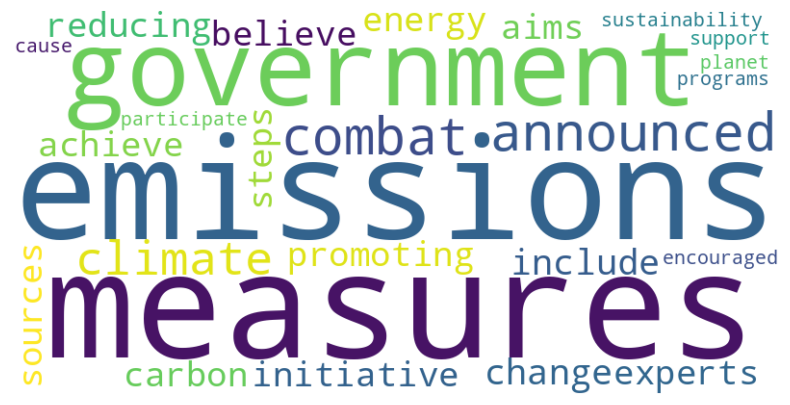

In [2]:
# Texto
texto = """
The government has announced new measures to combat climate change. These measures include reducing carbon emissions and promoting renewable energy sources. The initiative aims to achieve net-zero emissions by 2050. Experts believe that these steps are crucial for the sustainability of our planet. The public is encouraged to participate in various programs to support this cause.
"""

# 1. Limpieza y normalización del texto

texto = re.sub(r'[^\w\s]', '', texto).strip().lower()
print(texto)

# 2. Tokenización del texto

tokens = word_tokenize(texto)
print("Tokens: ")
print(tokens)

# 3. Eliminación de stop words

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
tokens_sin_stopwords = [word for word in tokens if word not in stop_words]
print("Tokens sin stopwords: ")
print(tokens_sin_stopwords)

# 4. Extracción del Part-of-Speech (POS)

pos_tags = pos_tag(tokens_sin_stopwords)
print("Part of Speech Tags: ")
print(pos_tags)

# 5. Lematización de las palabras y mostrar el DataFrame

lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in tokens_sin_stopwords]
df_lemmatized = pd.DataFrame({
    'Original': tokens_sin_stopwords,
    'Lematizado': lemmatized_words
})
display(df_lemmatized)

# 6. Extracción de palabras especiales y mostrar el DataFrame
special_words = [word for word, pos in pos_tags if pos.startswith('NN') or pos.startswith('VB')]
df_special = pd.DataFrame({
    'Palabra Especial': special_words
})
display(df_special)

# 7. Mostrar un WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(special_words))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


## Codigo Texto (Twitter)

just watched an amazing football match  sports football teama
cant believe how good the game was last night exciting teamb
the team played exceptionally well and deserved the win victory 
feeling inspired after that match motivation sportslife
what a goal by player1 absolutely stunning goaloftheseason
Tokens: 
['just', 'watched', 'an', 'amazing', 'football', 'match', 'sports', 'football', 'teama', 'cant', 'believe', 'how', 'good', 'the', 'game', 'was', 'last', 'night', 'exciting', 'teamb', 'the', 'team', 'played', 'exceptionally', 'well', 'and', 'deserved', 'the', 'win', 'victory', 'feeling', 'inspired', 'after', 'that', 'match', 'motivation', 'sportslife', 'what', 'a', 'goal', 'by', 'player1', 'absolutely', 'stunning', 'goaloftheseason']
Tokens sin stopwords: 
['watched', 'amazing', 'football', 'match', 'sports', 'football', 'teama', 'cant', 'believe', 'good', 'game', 'last', 'night', 'exciting', 'teamb', 'team', 'played', 'exceptionally', 'well', 'deserved', 'win', 'victory', 'feelin

[nltk_data] Downloading package stopwords to /home/juan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Original,Lematizado
0,watched,watched
1,amazing,amazing
2,football,football
3,match,match
4,sports,sport
5,football,football
6,teama,teama
7,cant,cant
8,believe,believe
9,good,good


,Palabra Especial
0,watched
1,amazing
2,football
3,match
4,sports
5,football
6,teama
7,cant
8,believe
9,game


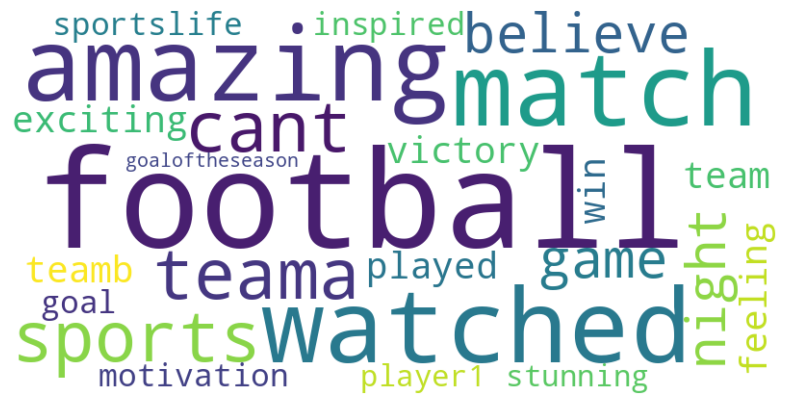

In [3]:
# Texto
texto = """
Just watched an amazing football match! ⚽️ #Sports #Football @TeamA
Can't believe how good the game was last night! #Exciting @TeamB
The team played exceptionally well and deserved the win. #Victory 🏆
Feeling inspired after that match! #Motivation #SportsLife
What a goal by @Player1! Absolutely stunning! #GoalOfTheSeason
"""

# 1. Limpieza y normalización del texto

texto = re.sub(r'[^\w\s]', '', texto).strip().lower()
print(texto)

# 2. Tokenización del texto

tokens = word_tokenize(texto)
print("Tokens: ")
print(tokens)

# 3. Eliminación de stop words

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
tokens_sin_stopwords = [word for word in tokens if word not in stop_words]
print("Tokens sin stopwords: ")
print(tokens_sin_stopwords)

# 4. Extracción del Part-of-Speech (POS)

pos_tags = pos_tag(tokens_sin_stopwords)
print("Part of Speech Tags: ")
print(pos_tags)

# 5. Lematización de las palabras y mostrar el DataFrame

lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in tokens_sin_stopwords]
df_lemmatized = pd.DataFrame({
    'Original': tokens_sin_stopwords,
    'Lematizado': lemmatized_words
})
display(df_lemmatized)

# 6. Extracción de palabras especiales y mostrar el DataFrame
special_words = [word for word, pos in pos_tags if pos.startswith('NN') or pos.startswith('VB')]
df_special = pd.DataFrame({
    'Palabra Especial': special_words
})
display(df_special)

# 7. Mostrar un WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(special_words))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## Codigo Texto (Reseña de producto)

this phone is absolutely fantastic    the camera quality is outstanding  and the battery life lasts all day    the screen is bright and clear   making it perfect for watching videos    the performance is smooth and fast  even with multiple apps running    highly recommended for anyone looking for a new smartphone    the design is sleek and modern  and the build quality is top  notch    customer service was also very helpful when i had questions about the features    dd
Tokens: 
['this', 'phone', 'is', 'absolutely', 'fantastic', 'the', 'camera', 'quality', 'is', 'outstanding', 'and', 'the', 'battery', 'life', 'lasts', 'all', 'day', 'the', 'screen', 'is', 'bright', 'and', 'clear', 'making', 'it', 'perfect', 'for', 'watching', 'videos', 'the', 'performance', 'is', 'smooth', 'and', 'fast', 'even', 'with', 'multiple', 'apps', 'running', 'highly', 'recommended', 'for', 'anyone', 'looking', 'for', 'a', 'new', 'smartphone', 'the', 'design', 'is', 'sleek', 'and', 'modern', 'and', 'the', 'build'

[nltk_data] Downloading package stopwords to /home/juan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Original,Lematizado
0,phone,phone
1,absolutely,absolutely
2,fantastic,fantastic
3,camera,camera
4,quality,quality
5,outstanding,outstanding
6,battery,battery
7,life,life
8,lasts,last
9,day,day


,Palabra Especial
0,phone
1,camera
2,quality
3,battery
4,life
5,lasts
6,day
7,making
8,watching
9,performance


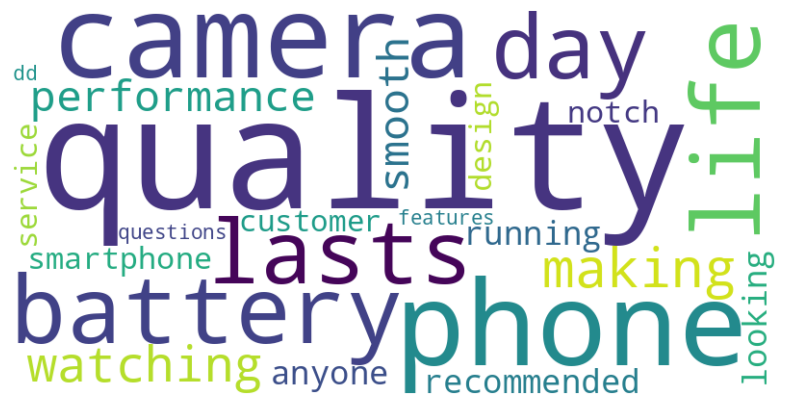

In [4]:
# Texto
texto = """
This phone is absolutely fantastic . . . The camera quality is outstanding , and the battery life lasts all day . . . The screen is bright and clear!!! >.< , making it perfect for watching videos . . . The performance is smooth and fast , even with multiple apps running . . . Highly recommended for anyone looking for a new smartphone . . . The design is sleek and modern , and the build quality is top - notch . . . Customer service was also very helpful when I had questions about the features . . . :DD
"""

# 1. Limpieza y normalización del texto

texto = re.sub(r'[^\w\s]', '', texto).strip().lower()
print(texto)

# 2. Tokenización del texto

tokens = word_tokenize(texto)
print("Tokens: ")
print(tokens)

# 3. Eliminación de stop words

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
tokens_sin_stopwords = [word for word in tokens if word not in stop_words]
print("Tokens sin stopwords: ")
print(tokens_sin_stopwords)

# 4. Extracción del Part-of-Speech (POS)

pos_tags = pos_tag(tokens_sin_stopwords)
print("Part of Speech Tags: ")
print(pos_tags)

# 5. Lematización de las palabras y mostrar el DataFrame

lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in tokens_sin_stopwords]
df_lemmatized = pd.DataFrame({
    'Original': tokens_sin_stopwords,
    'Lematizado': lemmatized_words
})
display(df_lemmatized)

# 6. Extracción de palabras especiales y mostrar el DataFrame
special_words = [word for word, pos in pos_tags if pos.startswith('NN') or pos.startswith('VB')]
df_special = pd.DataFrame({
    'Palabra Especial': special_words
})
display(df_special)

# 7. Mostrar un WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(special_words))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## Codigo Texto (Blog)

today we are going to discuss the importance of daily meditation meditation can help reduce stress and improve concentration by setting aside just a few minutes each day you can experience significant benefits regular practice can lead to a calmer mind and a more focused outlook on life start your meditation journey today and see the positive changes it brings many people find that meditation helps them to be more present and mindful in their daily activities it can also improve sleep quality and overall wellbeing
Tokens: 
['today', 'we', 'are', 'going', 'to', 'discuss', 'the', 'importance', 'of', 'daily', 'meditation', 'meditation', 'can', 'help', 'reduce', 'stress', 'and', 'improve', 'concentration', 'by', 'setting', 'aside', 'just', 'a', 'few', 'minutes', 'each', 'day', 'you', 'can', 'experience', 'significant', 'benefits', 'regular', 'practice', 'can', 'lead', 'to', 'a', 'calmer', 'mind', 'and', 'a', 'more', 'focused', 'outlook', 'on', 'life', 'start', 'your', 'meditation', 'journe

[nltk_data] Downloading package stopwords to /home/juan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Original,Lematizado
0,today,today
1,going,going
2,discuss,discus
3,importance,importance
4,daily,daily
5,meditation,meditation
6,meditation,meditation
7,help,help
8,reduce,reduce
9,stress,stress


,Palabra Especial
0,today
1,going
2,importance
3,meditation
4,meditation
5,help
6,reduce
7,stress
8,improve
9,concentration


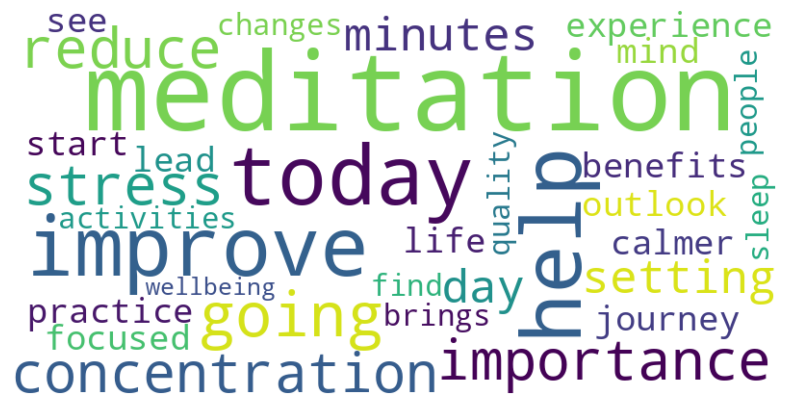

In [5]:
# Texto
texto = """
Today, we are going to discuss the importance of daily meditation. Meditation can help reduce stress and improve concentration. By setting aside just a few minutes each day, you can experience significant benefits. Regular practice can lead to a calmer mind and a more focused outlook on life. Start your meditation journey today and see the positive changes it brings. Many people find that meditation helps them to be more present and mindful in their daily activities. It can also improve sleep quality and overall well-being.
"""

# 1. Limpieza y normalización del texto

texto = re.sub(r'[^\w\s]', '', texto).strip().lower()
print(texto)

# 2. Tokenización del texto

tokens = word_tokenize(texto)
print("Tokens: ")
print(tokens)

# 3. Eliminación de stop words

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
tokens_sin_stopwords = [word for word in tokens if word not in stop_words]
print("Tokens sin stopwords: ")
print(tokens_sin_stopwords)

# 4. Extracción del Part-of-Speech (POS)

pos_tags = pos_tag(tokens_sin_stopwords)
print("Part of Speech Tags: ")
print(pos_tags)

# 5. Lematización de las palabras y mostrar el DataFrame

lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in tokens_sin_stopwords]
df_lemmatized = pd.DataFrame({
    'Original': tokens_sin_stopwords,
    'Lematizado': lemmatized_words
})
display(df_lemmatized)

# 6. Extracción de palabras especiales y mostrar el DataFrame
special_words = [word for word, pos in pos_tags if pos.startswith('NN') or pos.startswith('VB')]
df_special = pd.DataFrame({
    'Palabra Especial': special_words
})
display(df_special)

# 7. Mostrar un WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(special_words))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## Codigo Texto (Conversación de WhatsApp)

alice hey are we still on for dinner tonight  
bob yes definitely   what time should we meet 
alice how about 7 pm at the new italian place downtown 
bob sounds perfect  ive heard great things about their pasta   
alice me too   cant wait to try it    see you there 
bob see you
Tokens: 
['alice', 'hey', 'are', 'we', 'still', 'on', 'for', 'dinner', 'tonight', 'bob', 'yes', 'definitely', 'what', 'time', 'should', 'we', 'meet', 'alice', 'how', 'about', '7', 'pm', 'at', 'the', 'new', 'italian', 'place', 'downtown', 'bob', 'sounds', 'perfect', 'ive', 'heard', 'great', 'things', 'about', 'their', 'pasta', 'alice', 'me', 'too', 'cant', 'wait', 'to', 'try', 'it', 'see', 'you', 'there', 'bob', 'see', 'you']
Tokens sin stopwords: 
['alice', 'hey', 'still', 'dinner', 'tonight', 'bob', 'yes', 'definitely', 'time', 'meet', 'alice', '7', 'pm', 'new', 'italian', 'place', 'downtown', 'bob', 'sounds', 'perfect', 'ive', 'heard', 'great', 'things', 'pasta', 'alice', 'cant', 'wait', 'try', 'see', 'bob', '

[nltk_data] Downloading package stopwords to /home/juan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Original,Lematizado
0,alice,alice
1,hey,hey
2,still,still
3,dinner,dinner
4,tonight,tonight
5,bob,bob
6,yes,yes
7,definitely,definitely
8,time,time
9,meet,meet


,Palabra Especial
0,alice
1,hey
2,dinner
3,bob
4,time
5,place
6,downtown
7,bob
8,sounds
9,heard


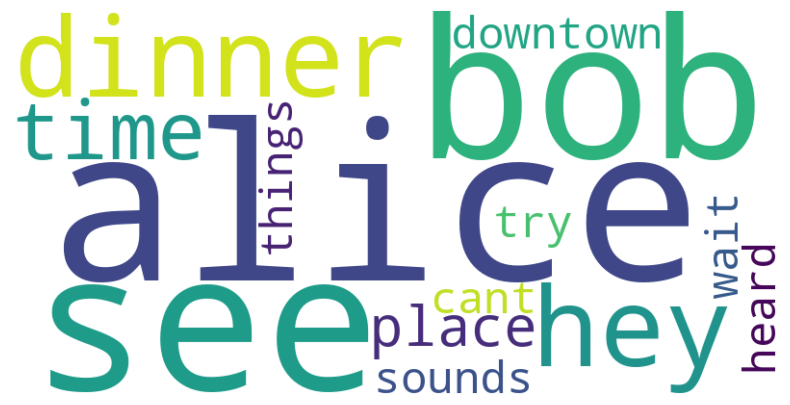

In [6]:
# Texto
texto = """
Alice: Hey, are we still on for dinner tonight ? ?
Bob: Yes, definitely ! ! What time should we meet ?
Alice: How about 7 PM at the new Italian place downtown ?
Bob: Sounds perfect ! I've heard great things about their pasta . . .
Alice: Me too ! ! Can't wait to try it . . . See you there !
Bob: See you ! 😊
"""

# 1. Limpieza y normalización del texto

texto = re.sub(r'[^\w\s]', '', texto).strip().lower()
print(texto)

# 2. Tokenización del texto

tokens = word_tokenize(texto)
print("Tokens: ")
print(tokens)

# 3. Eliminación de stop words

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
tokens_sin_stopwords = [word for word in tokens if word not in stop_words]
print("Tokens sin stopwords: ")
print(tokens_sin_stopwords)

# 4. Extracción del Part-of-Speech (POS)

pos_tags = pos_tag(tokens_sin_stopwords)
print("Part of Speech Tags: ")
print(pos_tags)

# 5. Lematización de las palabras y mostrar el DataFrame

lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in tokens_sin_stopwords]
df_lemmatized = pd.DataFrame({
    'Original': tokens_sin_stopwords,
    'Lematizado': lemmatized_words
})
display(df_lemmatized)

# 6. Extracción de palabras especiales y mostrar el DataFrame
special_words = [word for word, pos in pos_tags if pos.startswith('NN') or pos.startswith('VB')]
df_special = pd.DataFrame({
    'Palabra Especial': special_words
})
display(df_special)

# 7. Mostrar un WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(special_words))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()